# V4 — Full race replay: Russell–Verstappen

## Goal

Follow both cars over all 51 laps on a shared UTC clock. This is a position replay, not a new pace model.

### Key assumptions

Lap starts and end estimates are approximate. Interpolation is allowed only across at most 2 seconds. Timing gaps older than 12 seconds stay blank. SC end candidates do not establish exact withdrawal times. Tyre age is age at stint start, not current tyre age.

## Setup

Install requirements.txt and select that Python kernel. Saved JSON or lossless .json.gz originals are accepted. No network request is made unless FETCH_MISSING is True. See https://openf1.org/docs/#location.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'docs/analysis_design.json').exists())


In [2]:
"""V4: synchronize two approximate car locations over the whole recorded race.

Preserve original responses, audit 51 laps, reject long interpolation gaps,
and export a reproducible MP4 plus a dedicated video player.
"""
from pathlib import Path
import argparse, datetime, gzip, hashlib, json, math, subprocess, time
from urllib.request import urlopen
from urllib.error import HTTPError, URLError
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from matplotlib import font_manager
import imageio_ffmpeg


LANGUAGE = 'en'
TEXT = {'language': 'en', 'title': 'Russell–Verstappen: full race replay', 'subtitle': 'All 51 recorded laps · synchronized approximate positions · 24× base speed', 'timeline': 'Published VER gap to RUS (seconds) · lap labels follow Russell · hatched SC ends are candidates', 'elapsed': 'RACE CLOCK', 'sampled': 'Sampled', 'sample_age': 'Sample age:', 'result': 'Final result: VER', 'no_gap': 'timing unavailable', 'sc_active': 'Inside SC candidate period', 'sc_outside': 'Outside SC candidate periods', 'sc_note': 'Withdrawal boundaries still need review', 'complete': 'end*', 'lap': 'Lap', 'laps': 'laps', 'age': 'Stint start age:', 'MEDIUM': 'Medium', 'SOFT': 'Soft', 'no_location': 'Location unavailable', 'note1': 'Map outline: Russell lap 29. Markers show approximate progress, not lateral placement or racing lines.', 'note2': 'Gap comes from published timing (max age 12s), not map distance. *End time uses recorded lap-duration estimates.', 'source': 'Original data retained · interpolation only across gaps ≤2s'}
SESSION = 11377
DRIVERS = (63, 3)
FPS, SPEED = 20, 24
MAX_LOCATION_GAP, MAX_TIMING_AGE = 2.0, 12.0
WIDTH, HEIGHT = 1280, 900
BG, PANEL, INK, MUTED, TRACK = '#101721', '#172230', '#f2f5f8', '#aab8c8', '#304052'
COLOURS = {63:'#00d7b6', 3:'#679cff'}



FETCH_MISSING = False
RENDER_FULL_VIDEO = False


## Steps

### Read preserved timing inputs

In [3]:
def read_raw(root, endpoint):
    """Read saved originals; never make a hidden network request."""
    return pd.DataFrame(json.loads((root/'data/raw'/f'{endpoint}_session_key-{SESSION}.json').read_bytes()))


### Download missing originals only

In [4]:
def download_locations(root):
    """Fetch missing originals only; existing JSON or gzip files are preserved."""
    folder = root/'data/raw/full_replay'
    folder.mkdir(parents=True,exist_ok=True)
    for driver in DRIVERS:
        path = folder/f'location_session_key-{SESSION}_driver_number-{driver}.json'
        if path.exists() or Path(str(path)+'.gz').exists():
            continue
        url = f'https://api.openf1.org/v1/location?session_key={SESSION}&driver_number={driver}'
        for attempt in range(3):
            try:
                with urlopen(url,timeout=50) as response:
                    body = response.read()
                rows = json.loads(body)
                assert isinstance(rows,list) and rows, 'Empty location response'
                path.write_bytes(body)
                receipt = {'url':url,'downloaded_host_utc':datetime.datetime.now(datetime.timezone.utc).isoformat(),
                           'sha256':hashlib.sha256(body).hexdigest(),'rows':len(rows)}
                (folder/f'request_{driver}.json').write_text(json.dumps(receipt,indent=2))
                break
            except (HTTPError,URLError,TimeoutError) as error:
                if attempt==2: raise
                print(type(error).__name__,'retry',attempt+1,flush=True)
                time.sleep(5*(attempt+1))
        time.sleep(1)


### Validate raw identity, time range and 51-lap coverage

In [5]:
def load_replay_inputs(root):
    """Validate identities, timing, coverage and raw hashes before rendering."""
    laps = read_raw(root,'laps').query('driver_number in @DRIVERS').copy()
    assert len(laps)==102 and not laps.duplicated(['driver_number','lap_number']).any()
    assert laps.date_start.notna().all()
    assert laps.lap_duration.notna().all() and laps.lap_duration.gt(0).all()
    laps['start'] = pd.to_datetime(laps.date_start,format='ISO8601',utc=True).astype('int64')/1e9
    laps['end'] = laps.start+laps.lap_duration
    start, end = float(laps.start.min()),float(laps.end.max())
    locations, receipts, coverage = {},[],[]
    for driver in DRIVERS:
        path = root/'data/raw/full_replay'/f'location_session_key-{SESSION}_driver_number-{driver}.json'
        if path.exists(): body = path.read_bytes()
        else:
            path = Path(str(path)+'.gz')
            body = gzip.decompress(path.read_bytes())
        raw = pd.DataFrame(json.loads(body))
        assert raw.session_key.eq(SESSION).all() and raw.driver_number.eq(driver).all()
        assert raw.date.notna().all()
        receipt_path = path.parent/f'request_{driver}.json'
        receipt = json.loads(receipt_path.read_text())
        assert hashlib.sha256(body).hexdigest()==receipt['sha256']
        raw['t'] = pd.to_datetime(raw.date,format='ISO8601',utc=True).astype('int64')/1e9
        # Keep boundary-support samples, but do not animate pre/post-race data.
        race = raw[raw.t.between(start-MAX_LOCATION_GAP,end+MAX_LOCATION_GAP)].sort_values('t').copy()
        duplicates = race[race.t.duplicated(keep=False)]
        if len(duplicates):
            assert duplicates.groupby('t')[['x','y','z']].nunique(dropna=False).le(1).all().all(), 'Conflicting duplicate times'
        duplicate_count = int(race.t.duplicated().sum())
        race = race.drop_duplicates('t')
        for col in ['x','y']:
            race[col] = pd.to_numeric(race[col],errors='coerce')
        assert race.t.min()<=start and race.t.max()>=end, 'Race endpoints are not covered'
        assert np.isfinite(race.t).all()
        driver_laps = laps[laps.driver_number.eq(driver)].sort_values('lap_number')
        assert driver_laps.lap_number.tolist()==list(range(1,52))
        for lap in driver_laps.itertuples():
            n = int(((race.t>=lap.start)&(race.t<lap.end)).sum())
            coverage.append({'driver_number':driver,'lap_number':lap.lap_number,'location_rows':n})
            assert n>=2, 'Lap has too few location observations'
        locations[driver] = race
        receipts.append({'driver_number':driver,'file':str(path.relative_to(root)),
                         'raw_rows':len(raw),'race_support_rows':len(race),
                         'outside_race_support_rows':int(len(raw)-len(race)-duplicate_count),
                         'identical_duplicate_times_removed':duplicate_count,
                         'invalid_xy_rows':int((~np.isfinite(race[['x','y']])).any(axis=1).sum()),
                         'max_sample_gap_seconds':round(float(race.t.diff().max()),3),'sha256_uncompressed':receipt['sha256'],
                         'url':receipt['url']})
    gaps = read_raw(root,'intervals').query('driver_number == 3').copy()
    gaps['t'] = pd.to_datetime(gaps.date,format='ISO8601',utc=True).astype('int64')/1e9
    gaps['gap'] = pd.to_numeric(gaps.gap_to_leader,errors='coerce')
    gaps = gaps.sort_values('t')
    assert not gaps.t.duplicated().any()
    positions = read_raw(root,'position').query('driver_number == 63').copy()
    positions['t'] = pd.to_datetime(positions.date,format='ISO8601',utc=True).astype('int64')/1e9
    assert len(positions)>0 and positions.position.eq(1).all(), 'Leader gap is not always gap to RUS'
    race_control = read_raw(root,'race_control').copy()
    race_control['t'] = pd.to_datetime(race_control.date,format='ISO8601',utc=True).astype('int64')/1e9
    race_control = race_control[race_control.t.between(start,end)].sort_values('t')
    if race_control.flag.eq('RED').any() or race_control.message.str.contains('VIRTUAL SAFETY CAR',na=False).any():
        raise ValueError('Implement VSC/RED display for this session before replaying it')
    sc_periods = []
    deployments = race_control[race_control.message.eq('SAFETY CAR DEPLOYED')].t.tolist()
    leader_laps = laps[laps.driver_number.eq(63)].sort_values('lap_number')
    for i,deployment in enumerate(deployments):
        next_deployment = deployments[i+1] if i+1<len(deployments) else end
        notices = race_control[(race_control.t>deployment)&(race_control.t<next_deployment)&race_control.message.eq('SAFETY CAR IN THIS LAP')]
        assert len(notices)==1
        restart = int(notices.iloc[0].lap_number)+1
        candidate_end = float(leader_laps[leader_laps.lap_number.eq(restart)].iloc[0].start)
        sc_periods.append({'start':deployment,'end_candidate':candidate_end,'restart_lap_candidate':restart})
    stints = read_raw(root,'stints').query('driver_number in @DRIVERS').copy()
    results = read_raw(root,'session_result').set_index('driver_number')
    assert results.loc[63,'position']==1 and results.loc[3,'position']==2
    finish_gap = float(results.loc[3,'gap_to_leader'])
    audit = {'session_key':SESSION,'drivers':list(DRIVERS),'start_utc':pd.Timestamp(start,unit='s',tz='UTC').round('ms').isoformat(),
             'end_estimated_utc':pd.Timestamp(end,unit='s',tz='UTC').round('ms').isoformat(),'race_seconds':round(end-start,3),
             'max_location_interpolation_gap_seconds':MAX_LOCATION_GAP,'max_timing_age_seconds':MAX_TIMING_AGE,
             'endpoint_definition':'first recorded lap start to latest last-lap start + recorded duration; approximate',
             'sources':receipts,'sc_periods':sc_periods,'sc_status':'CANDIDATE_WITHDRAWAL_BOUNDARIES',
             'official_finish_gap_seconds':finish_gap}
    return {'laps':laps,'locations':locations,'gaps':gaps,'sc_periods':sc_periods,'stints':stints,
            'start':start,'end':end,'finish_gap':finish_gap,'audit':audit,'lap_coverage':pd.DataFrame(coverage)}


In [6]:
if FETCH_MISSING:
    download_locations(ROOT)
context = load_replay_inputs(ROOT)
pd.DataFrame(context['audit']['sources'])[['driver_number','raw_rows','race_support_rows','max_sample_gap_seconds','invalid_xy_rows']]

,driver_number,raw_rows,race_support_rows,max_sample_gap_seconds,invalid_xy_rows
0,63,37095,22538,1.339,0
1,3,37095,22538,1.339,0


In [7]:
coverage=context['lap_coverage']
coverage.groupby('driver_number').agg(laps=('lap_number','nunique'),min_location_rows=('location_rows','min'),total_location_rows=('location_rows','sum'))

,laps,min_location_rows,total_location_rows
driver_number,,,
3,51,394,22531
63,51,393,22526


### Synchronize both cars onto a shared frame clock

In [8]:
def build_replay_frames(context,speed=SPEED,fps=FPS):
    """Put both drivers on one clock and hide markers across long sample gaps."""
    start,end = context['start'],context['end']
    count = math.ceil((end-start)/speed*fps)+1
    frames = pd.DataFrame({'frame':np.arange(count),'race_time':np.linspace(start,end,count)})
    frames['utc'] = pd.to_datetime(frames.race_time,unit='s',utc=True).dt.strftime('%H:%M:%S')
    for driver in DRIVERS:
        source = context['locations'][driver]
        times = source.t.to_numpy()
        right = np.searchsorted(times,frames.race_time,side='left').clip(1,len(times)-1)
        left = right-1
        span = times[right]-times[left]
        xy = source[['x','y']].to_numpy()
        fraction = (frames.race_time.to_numpy()-times[left])/span
        interpolated = xy[left]+fraction[:,None]*(xy[right]-xy[left])
        valid = (span<=MAX_LOCATION_GAP)&np.isfinite(xy[left]).all(axis=1)&np.isfinite(xy[right]).all(axis=1)
        valid &= frames.race_time.between(times[0],times[-1]).to_numpy()
        frames[f'x_{driver}'] = np.where(valid,interpolated[:,0],np.nan)
        frames[f'y_{driver}'] = np.where(valid,interpolated[:,1],np.nan)
        frames[f'valid_{driver}'] = valid
        frames[f'bracket_seconds_{driver}'] = span
        driver_laps = context['laps'][context['laps'].driver_number.eq(driver)].sort_values('lap_number')
        index = np.searchsorted(driver_laps.start.to_numpy(),frames.race_time,side='right')-1
        assert (index>=0).all()
        frames[f'lap_{driver}'] = driver_laps.lap_number.to_numpy()[index]
        frames[f'finished_est_{driver}'] = frames.race_time>=driver_laps.end.iloc[-1]
        compound,age = {},{}
        for lap in driver_laps.lap_number:
            found = context['stints'].query('driver_number == @driver and lap_start <= @lap and lap_end >= @lap')
            assert len(found)==1, 'Unresolved tyre-stint context'
            compound[int(lap)] = found.iloc[0].compound
            age[int(lap)] = int(found.iloc[0].tyre_age_at_start)
        frames[f'compound_{driver}'] = frames[f'lap_{driver}'].map(compound)
        frames[f'start_age_{driver}'] = frames[f'lap_{driver}'].map(age)
    gaps = context['gaps']
    index = np.searchsorted(gaps.t.to_numpy(),frames.race_time,side='right')-1
    safe_index = index.clip(0)
    ages = frames.race_time.to_numpy()-gaps.t.to_numpy()[safe_index]
    valid = (index>=0)&(ages>=0)&(ages<=MAX_TIMING_AGE)
    frames['timing_age_seconds'] = np.where(valid,ages,np.nan)
    frames['gap_seconds'] = np.where(valid,gaps.gap.to_numpy()[safe_index],np.nan)
    frames['sc_candidate'] = False
    for period in context['sc_periods']:
        frames.loc[frames.race_time.between(period['start'],period['end_candidate'],inclusive='left'),'sc_candidate'] = True
    assert frames.race_time.is_monotonic_increasing and not frames.frame.duplicated().any()
    return frames


### Save alignment and audit tables

In [9]:
def save_replay_tables(root,context,frames,speed=SPEED,fps=FPS):
    """Save frame-level alignment, lap coverage and source audits separately."""
    folder = root/'data/processed/v4'
    folder.mkdir(parents=True,exist_ok=True)
    frames.to_csv(folder/'replay_frames.csv',index=False)
    context['lap_coverage'].to_csv(folder/'lap_location_coverage.csv',index=False)
    audit = dict(context['audit'],fps=fps,base_speed=speed,frames=len(frames),encoded_seconds=len(frames)/fps)
    audit['hidden_location_frames'] = {str(d):int((~frames[f'valid_{d}']).sum()) for d in DRIVERS}
    audit['missing_or_stale_gap_frames'] = int(frames.gap_seconds.isna().sum())
    (folder/'replay_audit.json').write_text(json.dumps(audit,indent=2))
    return audit


In [10]:
frames=build_replay_frames(context)
audit=save_replay_tables(ROOT,context,frames)
{k:audit[k] for k in ['race_seconds','frames','encoded_seconds','hidden_location_frames','missing_or_stale_gap_frames']}

{'race_seconds': 5882.755,
 'frames': 4904,
 'encoded_seconds': 245.2,
 'hidden_location_frames': {'63': 0, '3': 0},
 'missing_or_stale_gap_frames': 52}

### Build the map and dynamic marker renderer

In [11]:
def make_frame_renderer(context,text=TEXT):
    """Draw a static reference trace and return a function for dynamic markers."""
    family = 'DejaVu Sans'
    if text['language']=='ko':
        available = {font.name for font in font_manager.fontManager.ttflist}
        family = next((name for name in ['Apple SD Gothic Neo','AppleGothic','Malgun Gothic','NanumGothic','Noto Sans CJK KR'] if name in available),'DejaVu Sans')
    path = font_manager.findfont(family)
    bold = font_manager.findfont(font_manager.FontProperties(family=family,weight='bold'))
    fonts = {(size,b):ImageFont.truetype(bold if b else path,size) for size in [16,18,20,22,24,28,34] for b in [False,True]}
    base = Image.new('RGB',(WIDTH,HEIGHT),BG)
    draw = ImageDraw.Draw(base)
    draw.text((50,25),'BAKU 2026  /  RUSSELL vs VERSTAPPEN',fill=COLOURS[63],font=fonts[18,True])
    draw.text((50,60),text['title'],fill=INK,font=fonts[34,True])
    draw.text((50,106),text['subtitle'],fill=MUTED,font=fonts[20,False])
    draw.text((815,210),f'{text["result"]} +{context["finish_gap"]:.3f}s',fill=MUTED,font=fonts[18,False])
    source = context['locations'][63]
    lap = context['laps'].query('driver_number == 63 and lap_number == 29').iloc[0]
    reference = source[source.t.between(lap.start,lap.end,inclusive='left')]
    assert len(reference)>100
    both = pd.concat(context['locations'].values())
    xmin,xmax,ymin,ymax = both.x.min(),both.x.max(),both.y.min(),both.y.max()
    scale = min(660/(xmax-xmin),405/(ymax-ymin))
    def pixel(x,y):return (WIDTH/2+(x-(xmin+xmax)/2)*scale,450-(y-(ymin+ymax)/2)*scale)
    points = [pixel(x,y) for x,y in zip(reference.x,reference.y)]
    points.append(points[0])
    draw.line(points,fill=TRACK,width=14,joint='curve')
    draw.line(points,fill='#637487',width=2,joint='curve')
    # The timeline plots published gap samples, not distance between markers.
    left,right,top,bottom = 80,1210,711,779
    max_gap = max(1,float(context['gaps'].gap.max())*1.08)
    def timeline_x(t):return left+(t-context['start'])/(context['end']-context['start'])*(right-left)
    def timeline_y(g):return bottom-g/max_gap*(bottom-top)
    for i,period in enumerate(context['sc_periods'],1):
        a,b = timeline_x(period['start']),timeline_x(period['end_candidate'])
        draw.rectangle((a,top,b,bottom),fill=PANEL)
        for x in range(int(a),int(b),12):draw.line((x,top,min(x+25,b),bottom),fill=TRACK,width=1)
        draw.text(((a+b)/2-14,top-22),f'SC{i}',fill=MUTED,font=fonts[16,False])
    selected = context['gaps'][context['gaps'].t.between(context['start'],context['end'])]
    previous = None
    for t,g in zip(selected.t,selected.gap):
        if not np.isfinite(g):previous=None;continue
        point = (timeline_x(t),timeline_y(g))
        if previous is not None:draw.line([previous,point],fill='#637487',width=2)
        previous = point
    for gap in [0,10,20]:
        if gap<=max_gap:draw.text((48,timeline_y(gap)-9),str(gap),fill=MUTED,font=fonts[16,False])
    draw.text((50,661),text['timeline'],fill=MUTED,font=fonts[18,False])
    for lap_number in [1,10,20,30,40,51]:
        t = float(context['laps'].query('driver_number == 63 and lap_number == @lap_number').iloc[0].start)
        draw.text((timeline_x(t)-10,785),str(lap_number),fill=MUTED,font=fonts[16,False])
    draw.text((50,826),text['note1'],fill=MUTED,font=fonts[16,False])
    draw.text((50,849),text['note2'],fill=MUTED,font=fonts[16,False])
    draw.text((50,876),'OpenF1 · session 11377 · 26 Sep 2026 | '+text['source'],fill=MUTED,font=fonts[16,False])
    def render(row):
        image = base.copy()
        canvas = ImageDraw.Draw(image)
        elapsed = row.race_time-context['start']
        canvas.text((50,149),f'{text["elapsed"]} {int(elapsed//60):02d}:{int(elapsed%60):02d}  |  {row.utc} UTC',fill=INK,font=fonts[22,True])
        gap = f'{row.gap_seconds:.3f}s' if np.isfinite(row.gap_seconds) else text['no_gap']
        canvas.text((50,183),f'{text["sampled"]} VER → RUS  {gap}',fill=COLOURS[3],font=fonts[28,True])
        if np.isfinite(row.timing_age_seconds):
            canvas.text((50,220),f'{text["sample_age"]} {row.timing_age_seconds:.1f}s',fill=MUTED,font=fonts[16,False])
        canvas.text((815,151),text['sc_active'] if row.sc_candidate else text['sc_outside'],fill=INK,font=fonts[20,True])
        canvas.text((815,179),text['sc_note'],fill=MUTED,font=fonts[16,False])
        for driver,label,card_x in [(63,'RUS',50),(3,'VER',1000)]:
            colour = COLOURS[driver]
            canvas.rectangle((card_x,292,card_x+230,424),fill=PANEL)
            canvas.text((card_x+15,305),label,fill=colour,font=fonts[24,True])
            lap_number = getattr(row,f'lap_{driver}')
            complete = ' · '+text['complete'] if getattr(row,f'finished_est_{driver}') else ''
            canvas.text((card_x+15,339),f'{text["lap"]} {lap_number:02d}/51{complete}',fill=INK,font=fonts[20,True])
            compound = getattr(row,f'compound_{driver}')
            age = getattr(row,f'start_age_{driver}')
            canvas.text((card_x+15,368),text.get(compound,compound),fill=MUTED,font=fonts[18,False])
            canvas.text((card_x+15,393),f'{text["age"]} {age} {text["laps"]}',fill=MUTED,font=fonts[16,False])
            if not getattr(row,f'valid_{driver}'):
                canvas.text((card_x+15,442),text['no_location'],fill=MUTED,font=fonts[18,False]);continue
            x,y = pixel(getattr(row,f'x_{driver}'),getattr(row,f'y_{driver}'))
            if driver==63:
                canvas.ellipse((x-10,y-10,x+10,y+10),fill=colour,outline=INK,width=2)
                label_pos = (x-53,y-32)
            else:
                canvas.line([(x,y-13),(x-12,y+9),(x+12,y+9),(x,y-13)],fill=colour,width=3)
                label_pos = (x+16,y+14)
            canvas.text(label_pos,label,fill=colour,font=fonts[18,True],stroke_width=2,stroke_fill=BG)
        x = timeline_x(row.race_time)
        canvas.line((x,top-5,x,bottom+3),fill=INK,width=2)
        if np.isfinite(row.gap_seconds):
            y = timeline_y(row.gap_seconds)
            canvas.ellipse((x-4,y-4,x+4,y+4),fill=COLOURS[3],outline=INK,width=1)
        return image
    return render


### Encode and decode-check the whole-race video

In [12]:
def render_video(root,context,frames,text=TEXT,fps=FPS):
    """Encode the full race; preserve the earlier short replay under its old name."""
    output = root/'outputs'/text['language']/'v4'
    output.mkdir(parents=True,exist_ok=True)
    render = make_frame_renderer(context,text)
    video = output/'01_full_race_replay.mp4'
    temporary = output/'01_full_race_replay.encoding.mp4'
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    command = [ffmpeg,'-y','-v','error','-f','rawvideo','-pix_fmt','rgb24','-s',f'{WIDTH}x{HEIGHT}',
               '-r',str(fps),'-i','-','-an','-c:v','libx264','-threads','2','-preset','veryfast',
               '-crf','21','-pix_fmt','yuv420p','-movflags','+faststart',str(temporary)]
    process = subprocess.Popen(command,stdin=subprocess.PIPE)
    try:
        for row in frames.itertuples(index=False):
            process.stdin.write(render(row).tobytes())
            if row.frame%1000==0:print(text['language'],'frame',row.frame,'/',len(frames),flush=True)
        process.stdin.close()
        assert process.wait()==0, 'FFmpeg encode failed'
    except BaseException:
        process.kill();process.wait();raise
    # Decode every frame to check that the finished file is readable.
    subprocess.run([ffmpeg,'-v','error','-xerror','-i',str(temporary),'-f','null','-'],check=True)
    temporary.replace(video)
    render(next(frames.head(1).itertuples(index=False))).save(output/'01_full_race_poster.png')
    selected = [0,len(frames)//4,len(frames)//2,3*len(frames)//4,len(frames)-1]
    for period in context['sc_periods']:
        selected.extend([int(np.argmin(np.abs(frames.race_time-period['start']))),int(np.argmin(np.abs(frames.race_time-period['end_candidate'])))])
    selected = sorted(set(selected))
    sheet = Image.new('RGB',(WIDTH*3,HEIGHT*math.ceil(len(selected)/3)),BG)
    for index,frame in enumerate(selected):
        sheet.paste(render(next(frames.iloc[[frame]].itertuples(index=False))),((index%3)*WIDTH,(index//3)*HEIGHT))
    sheet.resize((1920,450*math.ceil(len(selected)/3))).save(output/'02_full_race_contact_sheet.png')
    # A lightweight animated preview samples the whole race; MP4 retains every video frame.
    gif_frames = [render(next(frames.iloc[[i]].itertuples(index=False))).resize((640,450)) for i in np.linspace(0,len(frames)-1,80,dtype=int)]
    gif_frames[0].save(output/'03_full_race_overview.gif',save_all=True,append_images=gif_frames[1:],duration=180,loop=0)
    (output/'video_validation.json').write_text(json.dumps({'status':'PASS','full_decode':'PASS','video':video.name,
        'frames':len(frames),'fps':fps,'seconds':len(frames)/fps,'resolution':[WIDTH,HEIGHT],
        'language':text['language'],'contact_frames':selected,'sha256':hashlib.sha256(video.read_bytes()).hexdigest(),
        'gif_status':'80-frame overview; not continuous full replay'},indent=2))
    print(text['language'],'complete:',str(video),flush=True)
    return output


Full encoding may take several minutes. By default this walkthrough renders three representative frames; the validated MP4 is already in outputs. Set RENDER_FULL_VIDEO=True to regenerate it.

In [13]:
if RENDER_FULL_VIDEO:
    render_video(ROOT,context,frames)
render=make_frame_renderer(context)
from IPython.display import display


### Start

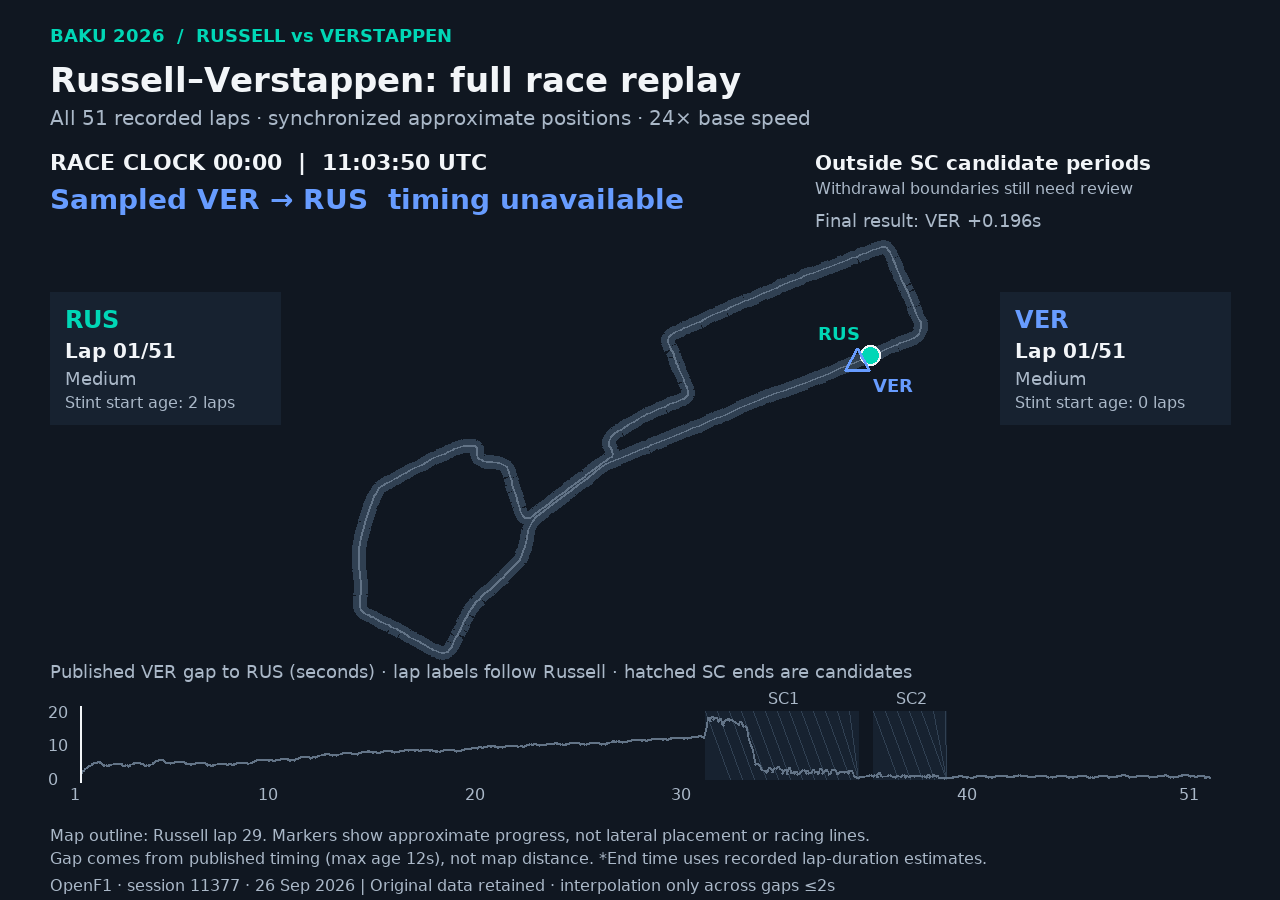

In [14]:
display(render(next(frames.iloc[[0]].itertuples(index=False))))

### First SC deployment

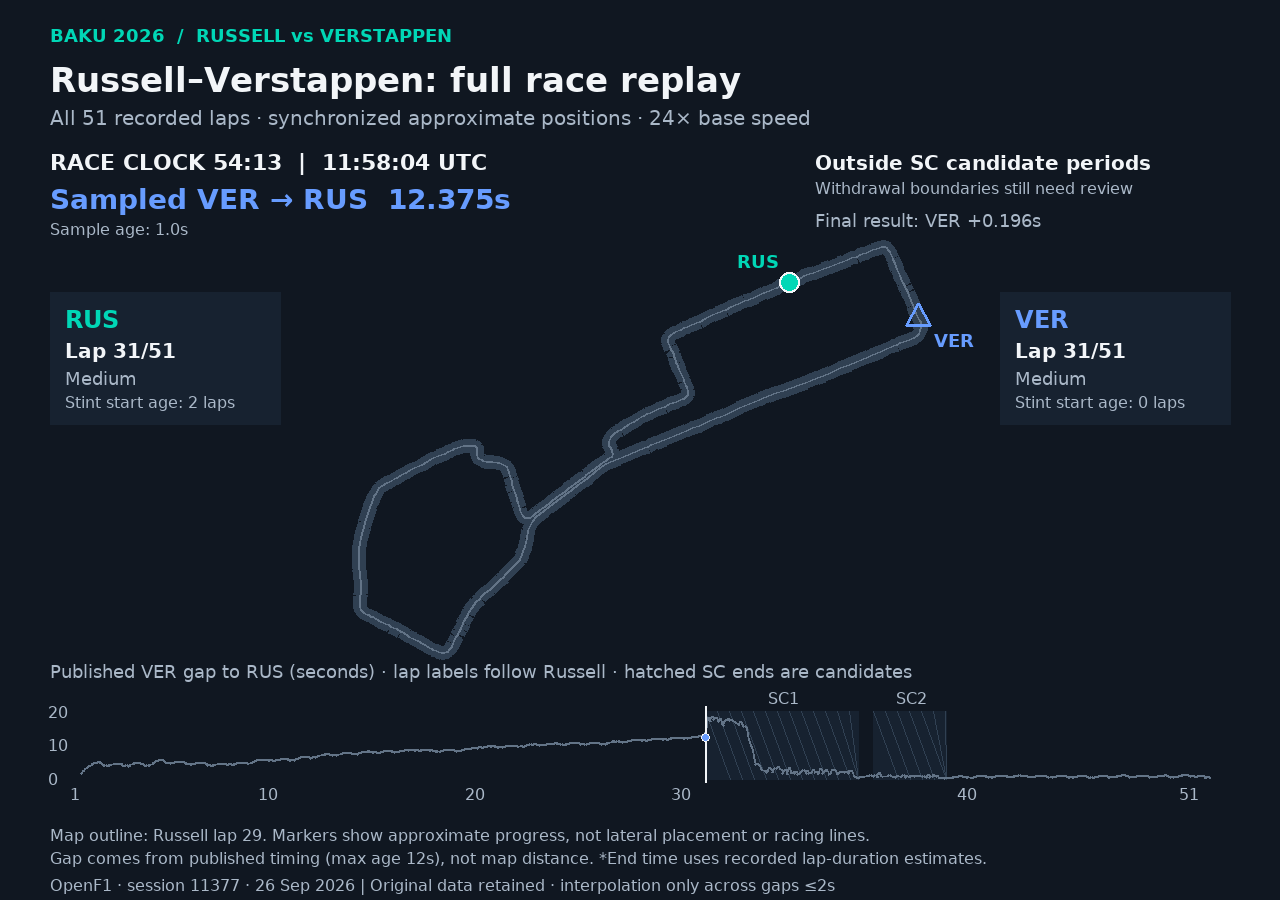

In [15]:
display(render(next(frames.iloc[[2712]].itertuples(index=False))))

### Final recorded lap end

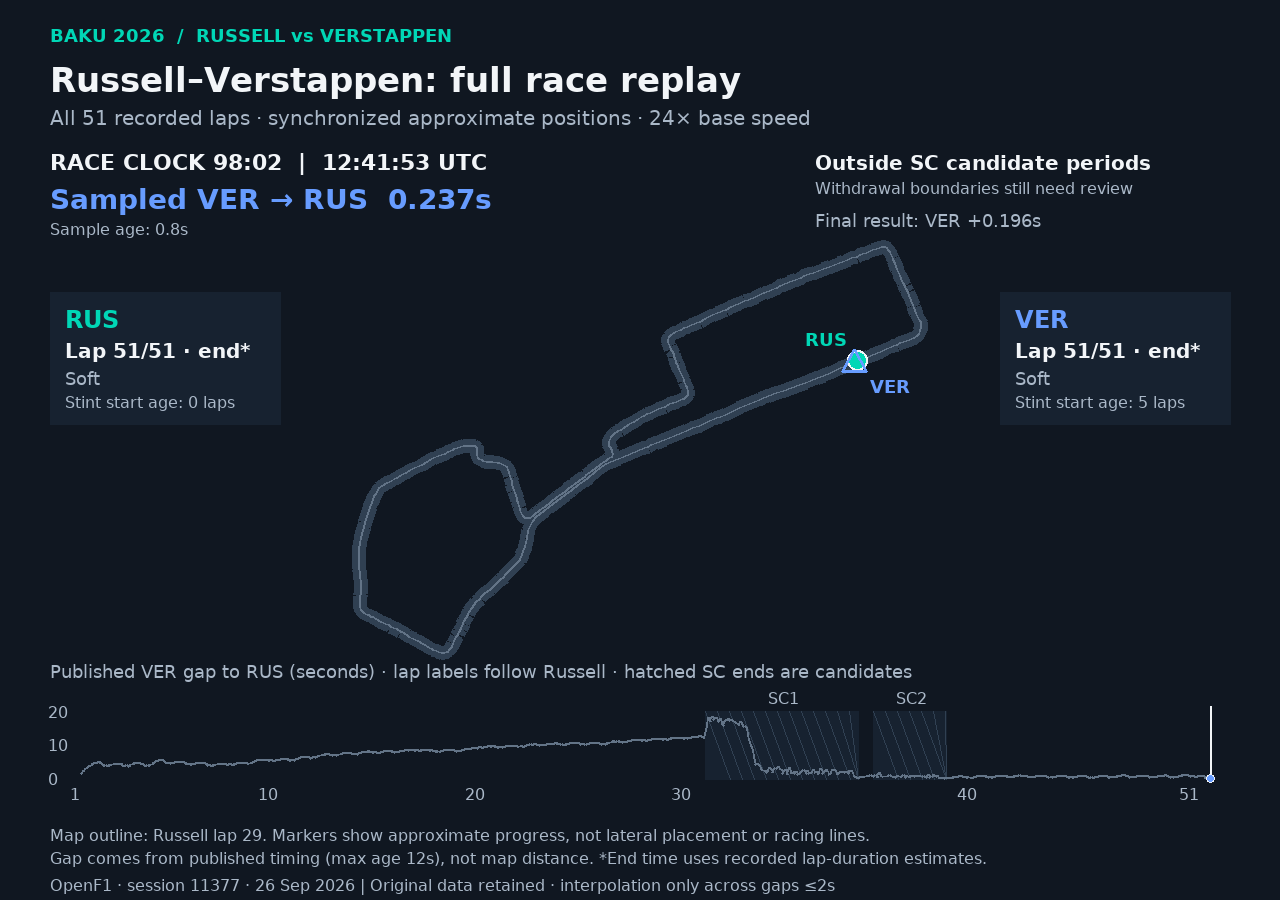

In [16]:
display(render(next(frames.iloc[[4903]].itertuples(index=False))))

## Checks

Every lap must have source observations and both markers must share the same clock. Gzip decompression must preserve original response bytes. An optional synthetic dropout check belongs to the execution report.

In [17]:
assert len(frames)==4904
assert coverage.groupby('driver_number').lap_number.nunique().eq(51).all()
assert frames[['lap_63','lap_3']].iloc[0].eq(1).all()
assert frames[['lap_63','lap_3']].iloc[-1].eq(51).all()
assert frames.timing_age_seconds.dropna().between(0,MAX_TIMING_AGE).all()
for driver in DRIVERS:
    assert frames.loc[frames[f'valid_{driver}'],f'bracket_seconds_{driver}'].le(MAX_LOCATION_GAP).all()
print('PASS: all laps, shared clock, interpolation and timing freshness')

PASS: all laps, shared clock, interpolation and timing freshness


## Next Steps

Open outputs/en/v4/replay.html for playback, lap seeking and speed changes. The GIF is an 80-frame overview, not the continuous replay. Continue pace analysis in V3; position distance cannot substitute for official timing.